In [11]:
%pip install matplotlib seaborn pandas folium jupyter

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jupyter_server-2.17.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached terminado-0.18.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached websocket_client-1.9.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached babel-2.18.0-py3-none-any.whl.metadata (2.2 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from utils import connect_to_warehouse
import pandas as pd
import matplotlib.pyplot as plt

organisation = "energy_systems_catapult"
datasets = "ssen_aggregated_smart_meter_usage"

catalog = connect_to_warehouse(organisation)
tables = catalog.list_tables(datasets)
TABLE_PATH = "ssen_aggregated_smart_meter_usage.ssen_march2026"  

try:
    table = catalog.load_table(TABLE_PATH)
    print(f"✅ Loaded table: {TABLE_PATH}")
    df = table.scan(limit=100).to_pandas()
except Exception as e:
    print(f"❌ Could not load table: {e}")
    print("\nMake sure to update TABLE_PATH with a valid table from your available tables.")

print(df.head())

✅ Loaded table: ssen_aggregated_smart_meter_usage.ssen_march2026
  dataset_id dno_alias secondary_substation_id lv_feeder_id  \
0  200200402      SSEN                       4            2   
1  200200403      SSEN                       4            3   
2  200200404      SSEN                       4            4   
3  200200405      SSEN                       4            5   
4  200200406      SSEN                       4            6   

   secondary_substation_latitude  secondary_substation_longitude  \
0                      56.471942                       -3.046251   
1                      56.471942                       -3.046251   
2                      56.471942                       -3.046251   
3                      56.471942                       -3.046251   
4                      56.471942                       -3.046251   

  output_area_code output_area_name          region  \
0        S01007849  Charleston - 05  North Scotland   
1        S01007849  Charleston - 05  

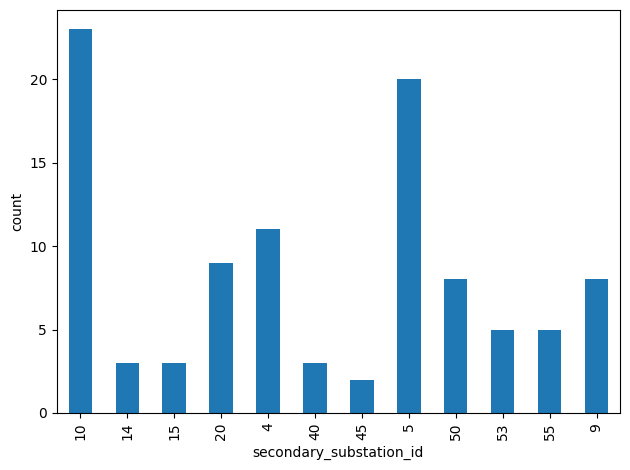

In [7]:
counts = df["secondary_substation_id"].value_counts().sort_index()
counts.plot(kind="bar", xlabel="secondary_substation_id", ylabel="count")
plt.tight_layout()

In [12]:
import folium

# One point per substation (rows repeat the same lat/lon per feeder/timestamp)
loc_cols = ["secondary_substation_id", "secondary_substation_latitude", "secondary_substation_longitude"]
locations = df.drop_duplicates(subset=["secondary_substation_id"])[loc_cols].dropna(subset=["secondary_substation_latitude", "secondary_substation_longitude"])

center = [locations["secondary_substation_latitude"].mean(), locations["secondary_substation_longitude"].mean()]
m = folium.Map(location=center, zoom_start=11, control_scale=True)

for _, row in locations.iterrows():
    folium.CircleMarker(
        location=[row["secondary_substation_latitude"], row["secondary_substation_longitude"]],
        radius=6,
        color="steelblue",
        fill=True,
        fill_opacity=0.7,
        popup=f"substation_id: {row['secondary_substation_id']}",
        tooltip=str(row["secondary_substation_id"]),
    ).add_to(m)

m

In [ ]:
plt.plot(df['data_collection_log_timestamp'], df['value'])